#UAS ML FRAUD TRANSACTION

Haikal Ali 1103223071 TK46GAB


# Hands-on End-to-End Models Deep Learning
## Fraud Detection Probability Prediction — Transaction-Only Version

Notebook ini membangun pipeline end-to-end untuk memprediksi probabilitas transaksi online sebagai fraud menggunakan **deep learning tabular model**.

> **Catatan penting:** instruksi awal tugas menyebut penggunaan `train_transaction.csv` dan `train_identity.csv`. Namun, pada kondisi saat ini file yang tersedia hanya `train_transaction.csv`. Karena itu notebook ini dibuat sebagai versi **transaction-only** agar tetap bisa dijalankan tanpa error di Google Colab Free. Jika dosen benar-benar mewajibkan identity table, file `train_identity.csv` tetap harus disediakan.

Pipeline yang dibuat:

1. Load dataset transaction.
2. Profiling missing value secara chunk agar hemat RAM.
3. Seleksi fitur berdasarkan missing ratio.
4. Feature engineering dari waktu dan nominal transaksi.
5. Split data berbasis waktu.
6. Encoding fitur kategorikal tanpa one-hot besar.
7. Imputasi missing value dan scaling.
8. Handling class imbalance dengan `class_weight`.
9. Hyperparameter tuning menggunakan Optuna.
10. Tracking eksperimen menggunakan MLflow.
11. Training final deep learning model.
12. Evaluasi model dengan ROC-AUC, PR-AUC, F1, precision, recall, log loss, dan confusion matrix.
13. Simpan model, preprocessor, hasil prediksi, dan artifact.

## 0. Setup Library

Google Colab biasanya sudah memiliki TensorFlow, pandas, NumPy, dan scikit-learn. Library yang perlu dipasang adalah `optuna` dan `mlflow`.

In [1]:
!pip -q install optuna mlflow joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

## 1. Import Library dan Konfigurasi

Konfigurasi di bawah sengaja dibuat ringan agar aman untuk Colab Free. Jika runtime masih kehabisan RAM, kurangi `MAX_NUM_FEATURES`, `TUNE_TRAIN_ROWS`, dan `TUNE_VAL_ROWS`.

In [2]:
!gdown --fuzzy "https://drive.google.com/file/d/1If2Xpro_dx8IfNkqDnw3qZ85v_eKtB6B/view"

Downloading...
From (original): https://drive.google.com/uc?id=1If2Xpro_dx8IfNkqDnw3qZ85v_eKtB6B
From (redirected): https://drive.google.com/uc?id=1If2Xpro_dx8IfNkqDnw3qZ85v_eKtB6B&confirm=t&uuid=4ff822df-36b3-484e-b0bb-0a822c046c42
To: /content/train_transaction.csv
100% 683M/683M [00:07<00:00, 90.9MB/s]


In [21]:
import os
import gc
import json
import math
import random
import warnings
from pathlib import Path

import joblib
import mlflow
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
  average_precision_score,
  classification_report,
  confusion_matrix,
  f1_score,
  log_loss,
  precision_recall_curve,
  precision_score,
  recall_score,
  roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG = {
  "DATA_DIR": "/content",
  "TRANSACTION_FILE": "train_transaction.csv",
  "TARGET": "isFraud",
  "ID_COL": "TransactionID",
  "TIME_COL": "TransactionDT",
  "MISSING_THRESHOLD": 0.80,
  "MAX_NUM_FEATURES": 140,
  "SCAN_CHUNKSIZE": 50000,
  "N_TRIALS": 5,
  "TUNE_TRAIN_ROWS": 80000,
  "TUNE_VAL_ROWS": 30000,
  "FINAL_EPOCHS": 20,
  "BATCH_SIZE_DEFAULT": 2048,
  "ARTIFACT_DIR": "/content/artifacts",
  "MLFLOW_ALLOW_FILE_STORE": "True"
}

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print(json.dumps(CONFIG, indent=2))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{
  "DATA_DIR": "/content",
  "TRANSACTION_FILE": "train_transaction.csv",
  "TARGET": "isFraud",
  "ID_COL": "TransactionID",
  "TIME_COL": "TransactionDT",
  "MISSING_THRESHOLD": 0.8,
  "MAX_NUM_FEATURES": 140,
  "SCAN_CHUNKSIZE": 50000,
  "N_TRIALS": 5,
  "TUNE_TRAIN_ROWS": 80000,
  "TUNE_VAL_ROWS": 30000,
  "FINAL_EPOCHS": 20,
  "BATCH_SIZE_DEFAULT": 2048,
  "ARTIFACT_DIR": "/content/artifacts",
  "MLFLOW_ALLOW_FILE_STORE": "True"
}


## 2. Mount Google Drive dan Resolve Path Dataset

Pastikan folder `DATA_DIR` berisi file berikut:

```text
train_transaction.csv
```

Jika file masih dalam bentuk zip, pandas tetap bisa membaca `train_transaction.csv.zip` selama isi zip hanya satu CSV utama.

In [4]:
def resolve_csv_path(data_dir, filename):
  data_dir = Path(data_dir)
  candidates = [
    data_dir / filename,
    data_dir / f"{filename}.zip",
    Path("/content") / filename,
    Path("/content") / f"{filename}.zip"
  ]

  for path in candidates:
    if path.exists():
      return path

  searched = "\n".join(str(p) for p in candidates)
  raise FileNotFoundError(
    f"File {filename} tidak ditemukan. Path yang dicek:\n{searched}\n"
    "Upload file ke /content atau taruh di DATA_DIR."
  )

transaction_path = resolve_csv_path(CONFIG["DATA_DIR"], CONFIG["TRANSACTION_FILE"])
print("Transaction path:", transaction_path)

Transaction path: /content/train_transaction.csv


## 3. Cek Header Dataset

Langkah ini memastikan target `isFraud` tersedia dan notebook tidak mencari identity table.

In [5]:
header_df = pd.read_csv(transaction_path, nrows=5)
print("Shape sample:", header_df.shape)
display(header_df.head(2))

assert CONFIG["TARGET"] in header_df.columns, "Kolom target isFraud tidak ditemukan."
assert CONFIG["ID_COL"] in header_df.columns, "Kolom TransactionID tidak ditemukan."
assert CONFIG["TIME_COL"] in header_df.columns, "Kolom TransactionDT tidak ditemukan."

print("Jumlah kolom:", len(header_df.columns))
print("Kolom object sample:", header_df.select_dtypes(include="object").columns.tolist())

Shape sample: (5, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,...,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Jumlah kolom: 394
Kolom object sample: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


## 4. Profiling Missing Value Secara Chunk

Dataset transaction berukuran besar. Membaca seluruh dataset hanya untuk menghitung missing value bisa boros RAM. Karena itu profiling dilakukan per chunk.

In [6]:
def profile_missing_csv(path, chunksize=50000):
  total_rows = 0
  missing_counts = None

  for chunk in pd.read_csv(path, chunksize=chunksize):
    total_rows += len(chunk)
    current_missing = chunk.isna().sum()

    if missing_counts is None:
      missing_counts = current_missing
    else:
      missing_counts = missing_counts.add(current_missing, fill_value=0)

    del chunk
    gc.collect()

  missing_ratio = (missing_counts / total_rows).sort_values(ascending=False)
  return total_rows, missing_ratio

n_rows, missing_ratio = profile_missing_csv(
  transaction_path,
  chunksize=CONFIG["SCAN_CHUNKSIZE"]
)

print("Total rows:", n_rows)
print("Top 20 kolom dengan missing ratio tertinggi:")
display(missing_ratio.head(20).to_frame("missing_ratio"))

Total rows: 590540
Top 20 kolom dengan missing ratio tertinggi:


,missing_ratio
dist2,0.936284
D7,0.934099
D13,0.895093
D14,0.894695
D12,0.890410
D6,0.876068
D8,0.873123
D9,0.873123
V162,0.861237
V142,0.861237


## 5. Seleksi Kolom Agar Aman untuk Colab Free

Strategi:

- Kolom dengan missing ratio sangat tinggi dibuang.
- Kolom penting seperti `TransactionDT`, `TransactionAmt`, `ProductCD`, `card`, `addr`, dan email domain diprioritaskan.
- Jumlah fitur numerik dibatasi dengan `MAX_NUM_FEATURES` agar training neural network tetap ringan.

In [7]:
sample_df = pd.read_csv(transaction_path, nrows=10000)
all_cols = sample_df.columns.tolist()

id_col = CONFIG["ID_COL"]
target_col = CONFIG["TARGET"]
time_col = CONFIG["TIME_COL"]

object_cols_all = sample_df.select_dtypes(include="object").columns.tolist()

priority_cols = [
  "TransactionDT", "TransactionAmt", "ProductCD",
  "card1", "card2", "card3", "card4", "card5", "card6",
  "addr1", "addr2",
  "dist1", "dist2",
  "P_emaildomain", "R_emaildomain",
  "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
  "D1", "D2", "D3", "D4", "D5", "D10", "D11", "D15",
  "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9"
]

eligible_cols = [
  col for col in all_cols
  if missing_ratio.get(col, 1.0) <= CONFIG["MISSING_THRESHOLD"]
]

priority_existing = [
  col for col in priority_cols
  if col in all_cols and missing_ratio.get(col, 1.0) <= 0.95
]

numeric_candidates = [
  col for col in eligible_cols
  if col not in object_cols_all
  and col not in priority_existing
  and col not in [id_col, target_col]
]

numeric_candidates = sorted(
  numeric_candidates,
  key=lambda col: (float(missing_ratio.get(col, 1.0)), col)
)

selected_numeric = numeric_candidates[:CONFIG["MAX_NUM_FEATURES"]]
selected_features = []

for col in priority_existing + object_cols_all + selected_numeric:
  if col not in selected_features and col not in [id_col, target_col]:
    selected_features.append(col)

selected_cols = [id_col, target_col] + selected_features
selected_cols = [col for col in selected_cols if col in all_cols]

print("Jumlah kolom asli:", len(all_cols))
print("Jumlah kolom dipakai:", len(selected_cols))
print("Jumlah fitur:", len(selected_features))
print("Contoh selected features:", selected_features[:40])

del sample_df
_ = gc.collect()

Jumlah kolom asli: 394
Jumlah kolom dipakai: 188
Jumlah fitur: 186
Contoh selected features: ['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3']


## 6. Load Dataset dengan Kolom Terpilih

Sekarang dataset dibaca penuh, tetapi hanya kolom yang sudah dipilih. Ini jauh lebih hemat RAM daripada membaca 394 kolom penuh.

In [8]:
def reduce_mem_usage(df):
  start_mem = df.memory_usage(deep=True).sum() / 1024**2

  for col in df.columns:
    col_type = df[col].dtype

    if pd.api.types.is_integer_dtype(col_type):
      df[col] = pd.to_numeric(df[col], downcast="integer")
    elif pd.api.types.is_float_dtype(col_type):
      df[col] = pd.to_numeric(df[col], downcast="float")
    elif pd.api.types.is_object_dtype(col_type):
      df[col] = df[col].astype("category")

  end_mem = df.memory_usage(deep=True).sum() / 1024**2
  print(f"Memory: {start_mem:.2f} MB -> {end_mem:.2f} MB")
  return df


df = pd.read_csv(transaction_path, usecols=selected_cols)
df = reduce_mem_usage(df)

print("Shape dataset:", df.shape)
print("Fraud rate:", df[target_col].mean())
display(df.head(3))

Memory: 1133.95 MB -> 397.06 MB
Shape dataset: (590540, 188)
Fraud rate: 0.03499000914417313


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D10,D11,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,...,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,13.0,13.0,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,0.0,315.0,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Exploratory Data Analysis Ringkas

Karena target fraud sangat imbalance, accuracy saja tidak cukup. Kita perlu fokus ke ROC-AUC, PR-AUC, recall, precision, F1, dan log loss.

,count,ratio
isFraud,,
0,569877,0.96501
1,20663,0.03499


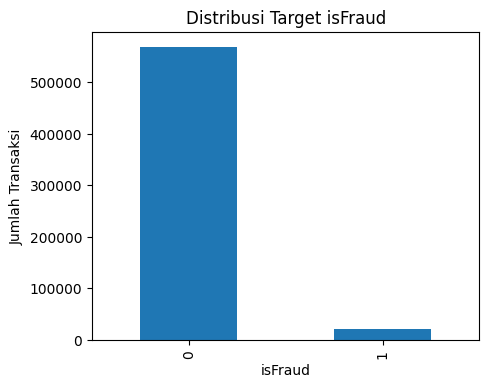

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511658,239.398010,0.251,43.970001,68.5,120.0,31937.390625
1,20663.0,149.244781,232.210709,0.292,35.043999,75.0,161.0,5191.000000


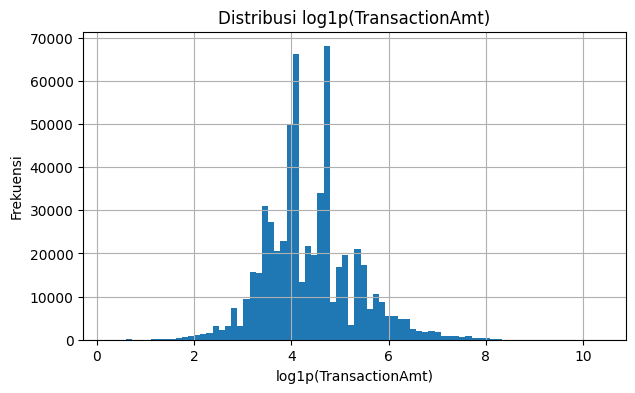

In [9]:
class_counts = df[target_col].value_counts().sort_index()
class_ratio = df[target_col].value_counts(normalize=True).sort_index()

summary_class = pd.DataFrame({
  "count": class_counts,
  "ratio": class_ratio
})

display(summary_class)

plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar")
plt.title("Distribusi Target isFraud")
plt.xlabel("isFraud")
plt.ylabel("Jumlah Transaksi")
plt.show()

if "TransactionAmt" in df.columns:
  display(df.groupby(target_col)["TransactionAmt"].describe())

  plt.figure(figsize=(7, 4))
  np.log1p(df["TransactionAmt"]).hist(bins=80)
  plt.title("Distribusi log1p(TransactionAmt)")
  plt.xlabel("log1p(TransactionAmt)")
  plt.ylabel("Frekuensi")
  plt.show()

## 8. Feature Engineering

Fitur tambahan:

- `TransactionAmt_log`: transformasi log untuk mengurangi skew pada nominal transaksi.
- `TransactionAmt_decimal`: bagian desimal dari nominal transaksi.
- `Transaction_hour`: jam relatif transaksi.
- `Transaction_day`: hari relatif transaksi.
- `Transaction_dow`: day-of-week relatif.
- `Transaction_week`: minggu relatif.

In [10]:
def add_features(data):
  data = data.copy()

  if "TransactionAmt" in data.columns:
    amt = data["TransactionAmt"].astype("float32")
    data["TransactionAmt_log"] = np.log1p(amt.clip(lower=0)).astype("float32")
    data["TransactionAmt_decimal"] = (amt - np.floor(amt)).astype("float32")

  if "TransactionDT" in data.columns:
    dt = data["TransactionDT"].astype("float64")
    data["Transaction_hour"] = ((dt // 3600) % 24).astype("int8")
    data["Transaction_day"] = (dt // (3600 * 24)).astype("int16")
    data["Transaction_dow"] = (data["Transaction_day"] % 7).astype("int8")
    data["Transaction_week"] = (data["Transaction_day"] // 7).astype("int16")

  return data


df = add_features(df)
df = reduce_mem_usage(df)
print("Shape setelah feature engineering:", df.shape)

Memory: 404.94 MB -> 404.38 MB
Shape setelah feature engineering: (590540, 194)


## 9. Time-Based Split

Fraud detection biasanya lebih realistis menggunakan split berbasis waktu. Data lama dipakai untuk training, data berikutnya untuk validation, dan data paling akhir untuk test.

Split:

- 70% awal: training
- 15% berikutnya: validation
- 15% terakhir: test

In [11]:
df = df.sort_values(time_col).reset_index(drop=True)

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

y = df[target_col].astype("int8")
ids = df[id_col].copy()

X_raw = df.drop(columns=[target_col, id_col])

X_train_raw = X_raw.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()
ids_train = ids.iloc[:train_end].copy()

X_val_raw = X_raw.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()
ids_val = ids.iloc[train_end:val_end].copy()

X_test_raw = X_raw.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()
ids_test = ids.iloc[val_end:].copy()

print("Train:", X_train_raw.shape, "fraud rate:", y_train.mean())
print("Valid:", X_val_raw.shape, "fraud rate:", y_val.mean())
print("Test :", X_test_raw.shape, "fraud rate:", y_test.mean())

del df, X_raw, y, ids
_ = gc.collect()

Train: (413378, 192) fraud rate: 0.03516878014795175
Valid: (88581, 192) fraud rate: 0.03434145019812375
Test : (88581, 192) fraud rate: 0.03480430340592226


## 10. Encoding Kategorikal Hemat RAM

One-hot encoding untuk dataset ini bisa sangat boros RAM. Karena itu notebook ini memakai dua encoding yang hemat:

1. **Frequency encoding**: kategori diganti dengan frekuensi kemunculannya di data train.
2. **Smoothed target encoding**: kategori diganti dengan rata-rata target fraud pada data train, dengan smoothing agar kategori langka tidak terlalu ekstrem.

Encoding hanya di-fit pada data training untuk menghindari data leakage.

In [12]:
class FraudFeatureEncoder:
  def __init__(self, cat_cols=None, smoothing=20.0):
    self.cat_cols = cat_cols or []
    self.smoothing = smoothing
    self.freq_maps_ = {}
    self.target_maps_ = {}
    self.global_mean_ = None

  @staticmethod
  def _clean_series(series):
    return series.astype("object").where(series.notna(), "__MISSING__").astype(str)

  def fit(self, X, y):
    self.global_mean_ = float(np.mean(y))
    y_array = pd.Series(np.asarray(y).astype("float32"), index=X.index)

    for col in self.cat_cols:
      values = self._clean_series(X[col])

      freq = values.value_counts(normalize=True)
      self.freq_maps_[col] = freq.astype("float32").to_dict()

      tmp = pd.DataFrame({"value": values, "target": y_array})
      stats = tmp.groupby("value")["target"].agg(["mean", "count"])
      smooth = (
        (stats["count"] * stats["mean"] + self.smoothing * self.global_mean_)
        / (stats["count"] + self.smoothing)
      )
      self.target_maps_[col] = smooth.astype("float32").to_dict()

      del tmp, stats, smooth, values, freq
      gc.collect()

    return self

  def transform(self, X):
    out = X.copy()

    for col in self.cat_cols:
      values = self._clean_series(out[col])
      out[f"{col}_freq"] = values.map(self.freq_maps_[col]).fillna(0).astype("float32")
      out[f"{col}_target_mean"] = values.map(self.target_maps_[col]).fillna(self.global_mean_).astype("float32")
      out = out.drop(columns=[col])

    for col in out.columns:
      if pd.api.types.is_object_dtype(out[col]) or str(out[col].dtype) == "category":
        out[col] = pd.to_numeric(out[col].astype("object"), errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan)
    return out.astype("float32")

In [13]:
object_or_category_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()

explicit_categorical_cols = [
  "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
  "addr1", "addr2",
  "P_emaildomain", "R_emaildomain",
  "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9"
]

cat_cols = []
for col in object_or_category_cols + explicit_categorical_cols:
  if col in X_train_raw.columns and col not in cat_cols:
    cat_cols.append(col)

num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

print("Categorical cols:", len(cat_cols), cat_cols)
print("Numeric cols:", len(num_cols))

Categorical cols: 20 ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2']
Numeric cols: 172


## 11. Fit Encoder, Imputer, dan Scaler

Semua preprocessing di-fit hanya pada training set.

In [14]:
encoder = FraudFeatureEncoder(cat_cols=cat_cols, smoothing=20.0)
encoder.fit(X_train_raw, y_train)

X_train_enc = encoder.transform(X_train_raw)
X_val_enc = encoder.transform(X_val_raw)
X_test_enc = encoder.transform(X_test_raw)

print("Encoded train shape:", X_train_enc.shape)
print("Encoded val shape:", X_val_enc.shape)
print("Encoded test shape:", X_test_enc.shape)

feature_names_before_impute = X_train_enc.columns.tolist()

imputer = SimpleImputer(strategy="median", add_indicator=True)
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train_enc)
X_val = imputer.transform(X_val_enc)
X_test = imputer.transform(X_test_enc)

X_train = scaler.fit_transform(X_train).astype("float32")
X_val = scaler.transform(X_val).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

y_train_np = y_train.to_numpy().astype("int8")
y_val_np = y_val.to_numpy().astype("int8")
y_test_np = y_test.to_numpy().astype("int8")

print("Final X_train:", X_train.shape, X_train.dtype)
print("Final X_val:", X_val.shape, X_val.dtype)
print("Final X_test:", X_test.shape, X_test.dtype)

# Hapus dataframe encoded agar RAM lega.
del X_train_enc, X_val_enc, X_test_enc
_ = gc.collect()

Encoded train shape: (413378, 212)
Encoded val shape: (88581, 212)
Encoded test shape: (88581, 212)
Final X_train: (413378, 319) float32
Final X_val: (88581, 319) float32
Final X_test: (88581, 319) float32


## 12. Handling Class Imbalance

Fraud rate hanya sekitar 3–4%. Karena itu model bisa terlihat bagus jika hanya menebak semua transaksi sebagai non-fraud. Notebook ini memakai `class_weight` agar kesalahan pada kelas fraud diberi bobot lebih tinggi saat training.

In [15]:
classes = np.array([0, 1])
weights = compute_class_weight(
  class_weight="balanced",
  classes=classes,
  y=y_train_np
)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print("Class weight:", class_weight)

Class weight: {0: 0.5182253535252231, 1: 14.217155041959003}


## 13. Setup MLflow

MLflow digunakan untuk mencatat parameter, metrik, dan artifact dari proses tuning dan final training.

In [23]:
ARTIFACT_DIR = Path(CONFIG["ARTIFACT_DIR"])
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_DB_PATH = "/content/mlflow_tracking.db"
MLFLOW_ARTIFACT_ROOT = "/content/mlflow_artifacts"
EXPERIMENT_NAME = "transaction_only_fraud_deep_learning"

Path(MLFLOW_ARTIFACT_ROOT).mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

existing_exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if existing_exp is None:
  mlflow.create_experiment(
    name=EXPERIMENT_NAME,
    artifact_location=f"file://{MLFLOW_ARTIFACT_ROOT}"
  )

mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow artifact root:", MLFLOW_ARTIFACT_ROOT)
print("Artifact dir:", ARTIFACT_DIR)

2026/06/17 11:04:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 11:04:39 INFO mlflow.store.db.utils: Updating database tables


MLflow tracking URI: sqlite:////content/mlflow_tracking.db
MLflow artifact root: /content/mlflow_artifacts
Artifact dir: /content/artifacts


## 14. Fungsi Model Deep Learning

Model yang digunakan adalah MLP untuk data tabular:

- Dense layer
- Batch normalization
- Dropout
- Sigmoid output untuk probabilitas fraud

Output model adalah probabilitas `isFraud = 1`.

In [24]:
def build_mlp_model(input_dim, params):
  tf.keras.backend.clear_session()

  inputs = tf.keras.Input(shape=(input_dim,), name="tabular_input")

  x = tf.keras.layers.Dense(
    params["units_1"],
    activation=params["activation"],
    kernel_regularizer=tf.keras.regularizers.l2(params["l2"])
  )(inputs)
  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.Dropout(params["dropout_1"])(x)

  x = tf.keras.layers.Dense(
    params["units_2"],
    activation=params["activation"],
    kernel_regularizer=tf.keras.regularizers.l2(params["l2"])
  )(x)
  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.Dropout(params["dropout_2"])(x)

  if params["use_third_layer"]:
    x = tf.keras.layers.Dense(
      params["units_3"],
      activation=params["activation"],
      kernel_regularizer=tf.keras.regularizers.l2(params["l2"])
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(params["dropout_3"])(x)

  outputs = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)

  model = tf.keras.Model(inputs=inputs, outputs=outputs)
  optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])

  model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
      tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
      tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
  )

  return model

## 15. Subset untuk Optuna

Optuna tidak perlu memakai seluruh data pada setiap trial karena Colab Free terbatas. Tuning dilakukan pada subset, lalu parameter terbaik dipakai untuk final training pada data train penuh.

In [25]:
def sample_rows(X, y, max_rows, seed=42):
  if len(y) <= max_rows:
    return X, y

  rng = np.random.default_rng(seed)
  idx = rng.choice(len(y), size=max_rows, replace=False)
  return X[idx], y[idx]

X_train_tune, y_train_tune = sample_rows(
  X_train,
  y_train_np,
  CONFIG["TUNE_TRAIN_ROWS"],
  seed=SEED
)

X_val_tune, y_val_tune = sample_rows(
  X_val,
  y_val_np,
  CONFIG["TUNE_VAL_ROWS"],
  seed=SEED + 1
)

print("Tune train:", X_train_tune.shape, y_train_tune.mean())
print("Tune valid:", X_val_tune.shape, y_val_tune.mean())

Tune train: (80000, 319) 0.0347125
Tune valid: (30000, 319) 0.0337


## 16. Hyperparameter Tuning dengan Optuna

Metric utama tuning adalah **validation PR-AUC**, karena dataset imbalance. PR-AUC biasanya lebih informatif dibanding accuracy untuk kasus fraud detection.

In [26]:
def objective(trial):
  params = {
    "units_1": trial.suggest_categorical("units_1", [64, 128, 256]),
    "units_2": trial.suggest_categorical("units_2", [32, 64, 128]),
    "units_3": trial.suggest_categorical("units_3", [16, 32, 64]),
    "use_third_layer": trial.suggest_categorical("use_third_layer", [False, True]),
    "dropout_1": trial.suggest_float("dropout_1", 0.10, 0.45),
    "dropout_2": trial.suggest_float("dropout_2", 0.10, 0.45),
    "dropout_3": trial.suggest_float("dropout_3", 0.05, 0.35),
    "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
    "l2": trial.suggest_float("l2", 1e-7, 1e-4, log=True),
    "activation": trial.suggest_categorical("activation", ["relu", "swish"]),
    "batch_size": trial.suggest_categorical("batch_size", [1024, 2048, 4096])
  }

  callbacks = [
    tf.keras.callbacks.EarlyStopping(
      monitor="val_pr_auc",
      mode="max",
      patience=2,
      restore_best_weights=True
    )
  ]

  with mlflow.start_run(run_name=f"optuna_trial_{trial.number}"):
    mlflow.log_params(params)

    model = build_mlp_model(X_train_tune.shape[1], params)
    history = model.fit(
      X_train_tune,
      y_train_tune,
      validation_data=(X_val_tune, y_val_tune),
      epochs=10,
      batch_size=params["batch_size"],
      class_weight=class_weight,
      callbacks=callbacks,
      verbose=0
    )

    best_pr_auc = float(max(history.history.get("val_pr_auc", [0.0])))
    best_roc_auc = float(max(history.history.get("val_roc_auc", [0.0])))
    best_val_loss = float(min(history.history.get("val_loss", [999.0])))

    mlflow.log_metric("best_val_pr_auc", best_pr_auc)
    mlflow.log_metric("best_val_roc_auc", best_roc_auc)
    mlflow.log_metric("best_val_loss", best_val_loss)

  del model, history
  tf.keras.backend.clear_session()
  gc.collect()

  return best_pr_auc

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=CONFIG["N_TRIALS"], gc_after_trial=True)

print("Best trial:", study.best_trial.number)
print("Best PR-AUC:", study.best_value)
print("Best params:")
print(json.dumps(study.best_params, indent=2))

[I 2026-06-17 11:04:52,076] A new study created in memory with name: no-name-c52471a6-258e-4db6-b21e-672cf58fd05c
[I 2026-06-17 11:05:17,003] Trial 0 finished with value: 0.24215248227119446 and parameters: {'units_1': 128, 'units_2': 32, 'units_3': 32, 'use_third_layer': False, 'dropout_1': 0.43946844825669795, 'dropout_2': 0.3913549242801476, 'dropout_3': 0.11370173320348284, 'learning_rate': 0.00018559980846490597, 'l2': 3.5498788321965023e-07, 'activation': 'swish', 'batch_size': 4096}. Best is trial 0 with value: 0.24215248227119446.
[I 2026-06-17 11:05:34,080] Trial 1 finished with value: 0.32136043906211853 and parameters: {'units_1': 256, 'units_2': 64, 'units_3': 32, 'use_third_layer': False, 'dropout_1': 0.12276805754484783, 'dropout_2': 0.4321099380386666, 'dropout_3': 0.3396896099223678, 'learning_rate': 0.0015635108708133452, 'l2': 8.200518402245825e-07, 'activation': 'swish', 'batch_size': 4096}. Best is trial 1 with value: 0.32136043906211853.
[I 2026-06-17 11:05:56,738]

Best trial: 1
Best PR-AUC: 0.32136043906211853
Best params:
{
  "units_1": 256,
  "units_2": 64,
  "units_3": 32,
  "use_third_layer": false,
  "dropout_1": 0.12276805754484783,
  "dropout_2": 0.4321099380386666,
  "dropout_3": 0.3396896099223678,
  "learning_rate": 0.0015635108708133452,
  "l2": 8.200518402245825e-07,
  "activation": "swish",
  "batch_size": 4096
}


## 17. Final Training dengan Parameter Terbaik

Model final dilatih pada training set penuh dan dipantau menggunakan validation set.

In [27]:
best_params = study.best_params.copy()

# Pastikan semua key tersedia walaupun Optuna memilih layer tertentu.
def with_default_params(params):
  defaults = {
    "units_1": 128,
    "units_2": 64,
    "units_3": 32,
    "use_third_layer": False,
    "dropout_1": 0.25,
    "dropout_2": 0.25,
    "dropout_3": 0.15,
    "learning_rate": 1e-3,
    "l2": 1e-6,
    "activation": "relu",
    "batch_size": CONFIG["BATCH_SIZE_DEFAULT"]
  }
  defaults.update(params)
  return defaults

best_params = with_default_params(best_params)

callbacks = [
  tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=4,
    restore_best_weights=True
  ),
  tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
  )
]

final_model = build_mlp_model(X_train.shape[1], best_params)
final_model.summary()

with mlflow.start_run(run_name="final_transaction_only_mlp") as run:
  mlflow.log_params(best_params)
  mlflow.log_param("n_features_after_preprocessing", X_train.shape[1])
  mlflow.log_param("n_train_rows", len(y_train_np))
  mlflow.log_param("n_val_rows", len(y_val_np))
  mlflow.log_param("n_test_rows", len(y_test_np))
  mlflow.log_param("transaction_only", True)
  mlflow.log_param("identity_table_used", False)

  history = final_model.fit(
    X_train,
    y_train_np,
    validation_data=(X_val, y_val_np),
    epochs=CONFIG["FINAL_EPOCHS"],
    batch_size=best_params["batch_size"],
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
  )

  for metric_name, values in history.history.items():
    for epoch, value in enumerate(values):
      mlflow.log_metric(metric_name, float(value), step=epoch)

  final_run_id = run.info.run_id

print("Final MLflow run_id:", final_run_id)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)      │ (None, 319)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        81,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,713 (389.50 KB)

 Trainable params: 99,073 (387.00 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - loss: 0.5256 - pr_auc: 0.2459 - roc_auc: 0.8448 - val_loss: 0.4258 - val_pr_auc: 0.2643 - val_roc_auc: 0.8557 - learning_rate: 0.0016
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4254 - pr_auc: 0.3694 - roc_auc: 0.8919 - val_loss: 0.3957 - val_pr_auc: 0.3007 - val_roc_auc: 0.8633 - learning_rate: 0.0016
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4004 - pr_auc: 0.4157 - roc_auc: 0.9026 - val_loss: 0.4389 - val_pr_auc: 0.3139 - val_roc_auc: 0.8543 - learning_rate: 0.0016
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3824 - pr_auc: 0.4460 - roc_auc: 0.9107 - val_loss: 0.3854 - val_pr_auc: 0.3124 - val_roc_auc: 0.8592 - learning_rate: 0.0016
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3700 - pr_auc: 0.4754 - roc_auc: 0.9167 - val_loss: 0.3470 - val_pr_auc: 0.3581 - val_roc_auc: 0.8619 - learning_rate: 0.0016
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - los

## 18. Evaluasi Model

Threshold tidak langsung memakai 0.5. Untuk data imbalance, threshold dipilih dari validation set berdasarkan F1 terbaik, lalu threshold tersebut digunakan untuk test set.

In [28]:
val_prob = final_model.predict(X_val, batch_size=best_params["batch_size"]).ravel()
test_prob = final_model.predict(X_test, batch_size=best_params["batch_size"]).ravel()

precision_curve, recall_curve, thresholds = precision_recall_curve(y_val_np, val_prob)
f1_curve = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-12)

# precision_recall_curve menghasilkan threshold lebih sedikit 1 elemen daripada precision/recall.
best_threshold_idx = int(np.nanargmax(f1_curve[:-1]))
best_threshold = float(thresholds[best_threshold_idx])

print("Best threshold from validation:", best_threshold)

val_pred = (val_prob >= best_threshold).astype("int8")
test_pred = (test_prob >= best_threshold).astype("int8")

metrics = {
  "val_roc_auc": float(roc_auc_score(y_val_np, val_prob)),
  "val_pr_auc": float(average_precision_score(y_val_np, val_prob)),
  "val_log_loss": float(log_loss(y_val_np, val_prob)),
  "val_f1": float(f1_score(y_val_np, val_pred)),
  "val_precision": float(precision_score(y_val_np, val_pred, zero_division=0)),
  "val_recall": float(recall_score(y_val_np, val_pred, zero_division=0)),
  "test_roc_auc": float(roc_auc_score(y_test_np, test_prob)),
  "test_pr_auc": float(average_precision_score(y_test_np, test_prob)),
  "test_log_loss": float(log_loss(y_test_np, test_prob)),
  "test_f1": float(f1_score(y_test_np, test_pred)),
  "test_precision": float(precision_score(y_test_np, test_pred, zero_division=0)),
  "test_recall": float(recall_score(y_test_np, test_pred, zero_division=0)),
  "best_threshold": best_threshold
}

print(json.dumps(metrics, indent=2))

with mlflow.start_run(run_id=final_run_id):
  mlflow.log_metrics(metrics)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Best threshold from validation: 0.8272725343704224
{
  "val_roc_auc": 0.8570466882552599,
  "val_pr_auc": 0.40665197726234387,
  "val_log_loss": 0.2687107946978236,
  "val_f1": 0.4225303292894281,
  "val_precision": 0.4468475073313783,
  "val_recall": 0.4007232084155161,
  "test_roc_auc": 0.8387466211109244,
  "test_pr_auc": 0.3092086193860747,
  "test_log_loss": 0.27174702913414,
  "test_f1": 0.35943379322702024,
  "test_precision": 0.40152121697357884,
  "test_recall": 0.32533246837495944,
  "best_threshold": 0.8272725343704224
}


Classification report - TEST
              precision    recall  f1-score   support

           0     0.9758    0.9825    0.9792     85498
           1     0.4015    0.3253    0.3594      3083

    accuracy                         0.9596     88581
   macro avg     0.6887    0.6539    0.6693     88581
weighted avg     0.9558    0.9596    0.9576     88581

Confusion matrix:
 [[84003  1495]
 [ 2080  1003]]


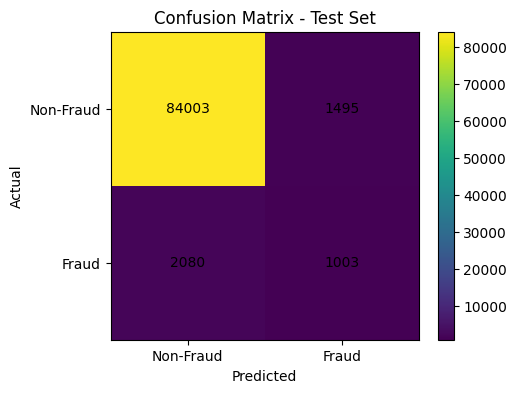

In [29]:
print("Classification report - TEST")
print(classification_report(y_test_np, test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test_np, test_pred)
print("Confusion matrix:\n", cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.yticks([0, 1], ["Non-Fraud", "Fraud"])
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

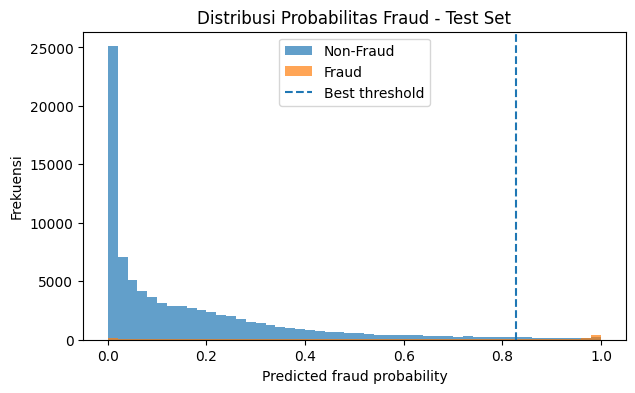

In [30]:
plt.figure(figsize=(7, 4))
plt.hist(test_prob[y_test_np == 0], bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(test_prob[y_test_np == 1], bins=50, alpha=0.7, label="Fraud")
plt.axvline(best_threshold, linestyle="--", label="Best threshold")
plt.title("Distribusi Probabilitas Fraud - Test Set")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

## 19. Simpan Artifact

Artifact yang disimpan:

- Model Keras final.
- Encoder, imputer, scaler, konfigurasi fitur.
- Metrics JSON.
- Prediksi probabilitas fraud pada test set.
- Optuna trials dataframe.

In [31]:
model_path = ARTIFACT_DIR / "transaction_only_fraud_mlp.keras"
preprocess_path = ARTIFACT_DIR / "transaction_only_preprocessor.joblib"
metrics_path = ARTIFACT_DIR / "transaction_only_metrics.json"
pred_path = ARTIFACT_DIR / "transaction_only_test_predictions.csv"
trials_path = ARTIFACT_DIR / "optuna_trials.csv"
config_path = ARTIFACT_DIR / "config.json"

final_model.save(model_path)

preprocessor_bundle = {
  "encoder": encoder,
  "imputer": imputer,
  "scaler": scaler,
  "cat_cols": cat_cols,
  "feature_names_before_impute": feature_names_before_impute,
  "selected_cols": selected_cols,
  "best_threshold": best_threshold,
  "config": CONFIG
}
joblib.dump(preprocessor_bundle, preprocess_path)

with open(metrics_path, "w") as f:
  json.dump(metrics, f, indent=2)

with open(config_path, "w") as f:
  json.dump(CONFIG, f, indent=2)

pred_df = pd.DataFrame({
  "TransactionID": ids_test.to_numpy(),
  "isFraud_true": y_test_np,
  "isFraud_probability": test_prob,
  "isFraud_pred": test_pred
})
pred_df.to_csv(pred_path, index=False)

trials_df = study.trials_dataframe()
trials_df.to_csv(trials_path, index=False)

with mlflow.start_run(run_id=final_run_id):
  mlflow.log_artifacts(str(ARTIFACT_DIR))

print("Saved artifacts:")
for path in ARTIFACT_DIR.iterdir():
  print("-", path)

Saved artifacts:
- /content/artifacts/transaction_only_fraud_mlp.keras
- /content/artifacts/transaction_only_preprocessor.joblib
- /content/artifacts/transaction_only_metrics.json
- /content/artifacts/transaction_only_test_predictions.csv
- /content/artifacts/config.json
- /content/artifacts/optuna_trials.csv


## 20. Zip Artifact untuk Diunduh

File zip ini bisa di-download dari panel file Colab.

In [32]:
!zip -r -q /content/fraud_artifacts_transaction_only.zip /content/artifacts
print("Artifact zip: /content/fraud_transaction.zip")

Artifact zip: /content/fraud_transaction.zip


## 21. Cara Menggunakan Model untuk Prediksi Baru

Untuk data baru, preprocessing harus sama persis:

1. Load preprocessor joblib.
2. Tambahkan feature engineering.
3. Transform dengan encoder.
4. Impute dan scale.
5. Prediksi probabilitas dengan model Keras.

In [33]:
# Contoh inference memakai beberapa baris dari validation raw.
loaded_model = tf.keras.models.load_model(model_path)
loaded_preprocessor = joblib.load(preprocess_path)

sample_new = X_val_raw.head(5).copy()
sample_new = add_features(sample_new)

sample_enc = loaded_preprocessor["encoder"].transform(sample_new)
sample_arr = loaded_preprocessor["imputer"].transform(sample_enc)
sample_arr = loaded_preprocessor["scaler"].transform(sample_arr).astype("float32")

sample_prob = loaded_model.predict(sample_arr).ravel()
sample_pred = (sample_prob >= loaded_preprocessor["best_threshold"]).astype("int8")

pd.DataFrame({
  "fraud_probability": sample_prob,
  "fraud_prediction": sample_pred
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step


,fraud_probability,fraud_prediction
0,0.084244,0
1,0.999745,1
2,0.457231,0
3,0.033129,0
4,0.103511,0


## 22. Kesimpulan Notebook

Notebook ini sudah membangun pipeline deep learning end-to-end untuk fraud probability prediction menggunakan `train_transaction.csv` saja. Karena identity table tidak tersedia, bagian identity tidak digunakan. Untuk laporan, jelaskan batasan ini secara eksplisit agar tidak terlihat seperti mengabaikan requirement.

Poin penting evaluasi:

- Gunakan PR-AUC sebagai metric penting karena fraud detection sangat imbalance.
- Accuracy tidak cukup untuk menilai model.
- Threshold dipilih dari validation set, bukan asal 0.5.
- Semua preprocessing di-fit hanya pada training set untuk mencegah data leakage.
- Optuna digunakan untuk tuning hyperparameter.
- MLflow digunakan untuk tracking parameter, metric, dan artifact.